# Volatility-Adaptive Trading Strategy

In this notebook, we use forecasted volatility regimes to dynamically adjust trading exposure and position sizing.

Objectives:
1. Generate regime-based trading signals
2. Dynamically adjust position sizing
3. Reduce exposure during risky periods
4. Increase exposure during stable market conditions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

In [4]:
low_threshold = sp500["rolling_vol"].quantile(0.33)

high_threshold = sp500["rolling_vol"].quantile(0.66)

In [5]:
conditions = [
    sp500["rolling_vol"] <= low_threshold,
    
    sp500["rolling_vol"] <= high_threshold
]

choices = [
    1.0,
    0.5
]

sp500["position_size"] = np.select(
    conditions,
    choices,
    default=0.2
)

## Position Sizing Logic

- Low volatility → larger exposure
- Medium volatility → moderate exposure
- High volatility → defensive positioning

This creates a volatility-adaptive portfolio allocation system.

In [6]:
sp500["strategy_return"] = (
    sp500["position_size"].shift(1)
    * sp500["log_return"]
)

In [7]:
sp500["cum_market"] = (
    1 + sp500["log_return"]
).cumprod()

sp500["cum_strategy"] = (
    1 + sp500["strategy_return"]
).cumprod()

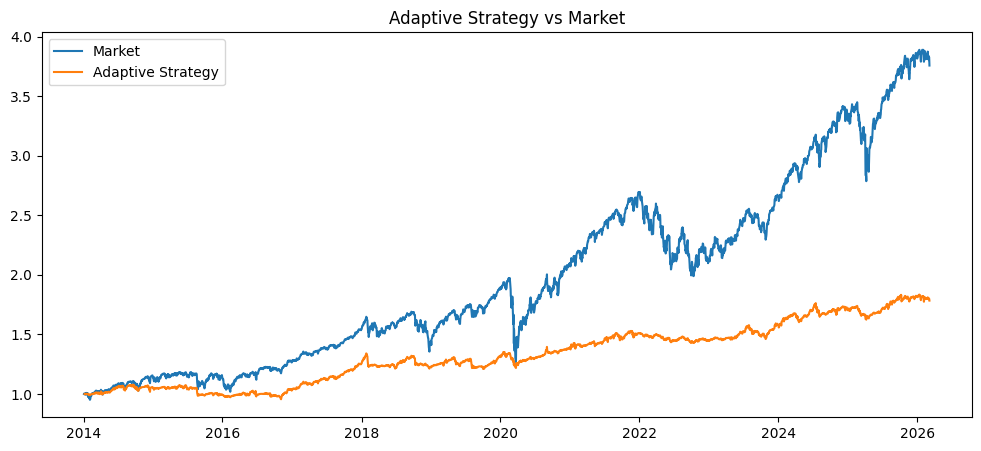

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["cum_market"],
    label="Market"
)

plt.plot(
    sp500["cum_strategy"],
    label="Adaptive Strategy"
)

plt.legend()

plt.title("Adaptive Strategy vs Market")

plt.show()

## Strategy Interpretation

The adaptive strategy dynamically reduces exposure during risky market periods while maintaining higher exposure during stable market environments.

This framework focuses on risk-adjusted exposure management rather than direct price prediction.

# Conclusion

The volatility-adaptive framework uses forecasted market risk to dynamically adjust portfolio exposure and position sizing.

Higher volatility leads to defensive positioning, while lower volatility allows larger market participation during stable periods.

## Drawdown Interpretation

The volatility-aware strategy attempts to reduce severe portfolio declines during unstable market periods.

Lower drawdowns indicate improved capital preservation during crises.

# Conclusion

The volatility-based framework demonstrates how volatility information can be integrated into portfolio exposure decisions.

Rather than forecasting exact price movements, the strategy dynamically adjusts risk exposure based on changing market volatility conditions.

This approach connects econometric volatility modeling with practical trading and portfolio management applications.